# Visualize Sam's data

# Importations

In [ ]:
import numpy as np 
import pandas as pd 
import seaborn as sns
from scipy.optimize import curve_fit
from scipy import signal
import glob

In [2]:
%matplotlib inline

import matplotlib.pyplot as plt

from matplotlib import rc
import matplotlib.colors as mplcolors
from mpltools import annotation

rc('lines', linewidth=1.5, markeredgecolor='k', markeredgewidth=0.5)
rc('xtick', direction='in', labelsize=9)
rc('ytick', direction='in', labelsize=9)

rc('font', family='serif', size=9)
rc('text', usetex=True)

rc('figure', dpi=200)
rc('savefig', dpi=600)

# Auxiliary functions

In [ ]:
# Cheat codes

In [10]:
def str2var(string):
    return globals()[string]

In [3]:
# I/O tasks

In [4]:
def sort_B_power(name: str, string: str ='rotation_data_1Hz_'):
    res = name[name.find(string)+len(string):]
    res = res[:res.find('_')]
    res = float(res)
    return res

def folderpath2filepaths(folderpath: str, string: str ='*.csv', sorting_key: None|function=None):
    filepaths = glob.glob(folderpath + string)
    if sorting_key is not None:
        filepaths.sort(key=sorting_key)
    return filepaths

def assemble_filepaths(folderpaths: list, string: str ='*.csv', sorting_key: None|function=None):
    res = []
    for folderpath in folderpaths:
        res = res + folderpath2filepaths(folderpath, string=string, sorting_key=None)
    res.sort(key=sorting_key)
    return res

def choose_condition(folderpaths, string):
    return [folderpath + string for folderpath in folderpaths]

In [5]:
# Data processing

In [ ]:
def moment(x: np.ndarray, delta: np.ndarray=np.arange(1,10,1), n: int|float=2, retrieve_mean: bool=False):
    '''
    Moment (order n) of the variable x, for the time steps delta (differences of indexes).
    '''
    res = np.zeros_like(delta) * np.nan
    for i, d in enumerate(delta):
        dx = x[d:] - x[:-d]
        if retrieve_mean:
            res[i] = np.nanmean((dx - np.nanmean(dx)) ** n)
        else:
            res[i] = np.nanmean((dx) ** n)
    return res



In [7]:
def pdf(data, bins=10, density=True, range=None):
    pdf, bins_edge = np.histogram(
        data, 
        bins=bins, 
        density=density, 
        range=range, 
    )
    bins_center = (bins_edge[0:-1] + bins_edge[1:]) / 2
    return pdf, bins_center

In [ ]:
# Theoretical functions

In [46]:
def gaussian(x, a, b):
    return b * np.exp(- x ** 2 / (2 * a ** 2))

def gaussian_brownian(x, D, t):
    return gaussian(x, 2*D*t, 1/np.sqrt(4*np.pi*D*t))

# Info on files

In [8]:
glob.glob('../sam/shell_stuck_on_surface/TriAmineChip2/*')

['../sam/shell_stuck_on_surface/TriAmineChip2/position1_neutral_pH_start',
 '../sam/shell_stuck_on_surface/TriAmineChip2/position1_NaOH_1e-3',
 '../sam/shell_stuck_on_surface/TriAmineChip2/position1_NaOH_10-5_NaCl_10-4',
 '../sam/shell_stuck_on_surface/TriAmineChip2/position1_NaOH_1e-5',
 '../sam/shell_stuck_on_surface/TriAmineChip2/position1_NaOH_10-5_NaCl_10-3']

In [9]:
glob.glob('../sam/shell_stuck_on_surface/TriAmineChip3/*')

['../sam/shell_stuck_on_surface/TriAmineChip3/position1_NaOH_2_going_back_from_salt',
 '../sam/shell_stuck_on_surface/TriAmineChip3/position2_NaOH_2_going_back_from_salt',
 '../sam/shell_stuck_on_surface/TriAmineChip3/position2_NaOH_10-5_NaCl_10-3',
 '../sam/shell_stuck_on_surface/TriAmineChip3/position3_NaOH_10-5_NaCl_10-3',
 '../sam/shell_stuck_on_surface/TriAmineChip3/position1_NaOH_1e-5',
 '../sam/shell_stuck_on_surface/TriAmineChip3/position3_NaOH_2_going_back_from_salt',
 '../sam/shell_stuck_on_surface/TriAmineChip3/position1_NaOH_10-5_NaCl_10-3']

# Load data

In [20]:
# One experimental condition

folderpaths_0 = [
    '../sam/shell_stuck_on_surface/TriAmineChip2/position1_NaOH_10-5_NaCl_10-3/', 
    '../sam/shell_stuck_on_surface/TriAmineChip3/position1_NaOH_10-5_NaCl_10-3/', 
    '../sam/shell_stuck_on_surface/TriAmineChip3/position2_NaOH_10-5_NaCl_10-3/', 
    '../sam/shell_stuck_on_surface/TriAmineChip3/position3_NaOH_10-5_NaCl_10-3/', 
]

folderpaths_0_1 = choose_condition(folderpaths_0, string='1.0Hz/')
filepaths_0_1 = assemble_filepaths(folderpaths_0_1, string='*.csv', sorting_key=sort_B_power)

folderpaths_0_0 = choose_condition(folderpaths_0, string='0.0Hz/')
filepaths_0_0 = assemble_filepaths(folderpaths_0_0, string='*.csv', sorting_key=None)[:]

filepaths_0_0

['../sam/shell_stuck_on_surface/TriAmineChip2/position1_NaOH_10-5_NaCl_10-3/0.0Hz/rotation_data_0Hz_0_0_particle_1.csv',
 '../sam/shell_stuck_on_surface/TriAmineChip3/position1_NaOH_10-5_NaCl_10-3/0.0Hz/rotation_data_0Hz_0_0_2_particle_1.csv',
 '../sam/shell_stuck_on_surface/TriAmineChip3/position1_NaOH_10-5_NaCl_10-3/0.0Hz/rotation_data_0Hz_0_0_2_particle_2.csv',
 '../sam/shell_stuck_on_surface/TriAmineChip3/position1_NaOH_10-5_NaCl_10-3/0.0Hz/rotation_data_0Hz_0_0_particle_1.csv',
 '../sam/shell_stuck_on_surface/TriAmineChip3/position1_NaOH_10-5_NaCl_10-3/0.0Hz/rotation_data_0Hz_0_0_particle_2.csv',
 '../sam/shell_stuck_on_surface/TriAmineChip3/position2_NaOH_10-5_NaCl_10-3/0.0Hz/rotation_data_0Hz_0_0_particle_1.csv',
 '../sam/shell_stuck_on_surface/TriAmineChip3/position2_NaOH_10-5_NaCl_10-3/0.0Hz/rotation_data_0Hz_0_0_particle_2.csv',
 '../sam/shell_stuck_on_surface/TriAmineChip3/position3_NaOH_10-5_NaCl_10-3/0.0Hz/rotation_data_0Hz_0_0_particle_1.csv',
 '../sam/shell_stuck_on_surf

In [21]:
# Another experimental condition

folderpaths_1 = [
    '../sam/shell_stuck_on_surface/TriAmineChip2/position1_NaOH_1e-5/',
    '../sam/shell_stuck_on_surface/TriAmineChip3/position1_NaOH_1e-5/',
]

folderpaths_1_1 = choose_condition(folderpaths_1, string='1.0Hz/')
filepaths_1_1 = assemble_filepaths(folderpaths_1_1, string='*.csv', sorting_key=sort_B_power)

folderpaths_1_0 = choose_condition(folderpaths_1, string='0.0Hz/')
filepaths_1_0 = assemble_filepaths(folderpaths_1_0, string='*.csv', sorting_key=None)

filepaths_1_0

['../sam/shell_stuck_on_surface/TriAmineChip2/position1_NaOH_1e-5/0.0Hz/rotation_data_0Hz_0_0_particle_1.csv',
 '../sam/shell_stuck_on_surface/TriAmineChip3/position1_NaOH_1e-5/0.0Hz/rotation_data_0Hz_0_0_particle_1.csv',
 '../sam/shell_stuck_on_surface/TriAmineChip3/position1_NaOH_1e-5/0.0Hz/rotation_data_0Hz_0_0_particle_2.csv']

In [14]:
# Calib 

calib = 130e-9

# Calib to be checked ! 

In [17]:
# # Look at one: 
# test = pd.read_csv('/home/nfares/postdoc/experiments/sam/shell_stuck_on_surface/TriAmineChip3/position2_NaOH_2_going_back_from_salt/1.0Hz/rotation_data_1Hz_3.5_3.2_c_particle_1.csv')
# test.head()

In [18]:
# filepaths_test = ['../tracking/tracking_datasam/TriAmineChip3_position2_NaOH_2_going_back_from_salt_1Hz_3p5_3p2_c']

In [396]:
filepaths = filepaths_1_0

filepaths

['../sam/shell_stuck_on_surface/TriAmineChip2/position1_NaOH_1e-5/0.0Hz/rotation_data_0Hz_0_0_particle_1.csv',
 '../sam/shell_stuck_on_surface/TriAmineChip3/position1_NaOH_1e-5/0.0Hz/rotation_data_0Hz_0_0_particle_1.csv',
 '../sam/shell_stuck_on_surface/TriAmineChip3/position1_NaOH_1e-5/0.0Hz/rotation_data_0Hz_0_0_particle_2.csv']

In [397]:
Ns = np.zeros(len(filepaths), dtype=int)
dts = np.zeros(len(filepaths), dtype=float)

for i, path in enumerate(filepaths):
    df = pd.read_csv(path)
    # Number of frames
    Ns[i] = int(len(df['frame']))
    # Frame rate / time step
    time = df['time_sec'].to_numpy()
    dt = np.nanmean(time[1:] - time[:-1])
    dt = np.round(dt, 4)
    dts[i] = dt

# fps = 1000

# Ns = np.zeros(len(filepaths), dtype=int)
# dts = np.zeros(len(filepaths), dtype=float)

# for i, path in enumerate(filepaths):
#     df = pd.read_pickle(path)
#     # Number of frames
#     Ns[i] = int(len(df['frame']))
#     # Frame rate / time step
#     time = np.arange(len(df)) / fps #df['time_sec'].to_numpy()
#     dt = np.nanmean(time[1:] - time[:-1])
#     dt = np.round(dt, 4)
#     dts[i] = dt

# print(Ns)
print('Length of the shortest trajectory:')
print(min(Ns))

print()
print('Time step (in s) of all the trajectories:')
print(dts)


Length of the shortest trajectory:
38190

Time step (in s) of all the trajectories:
[0.001 0.001 0.001]


In [398]:
dt = dts[0]

In [399]:
df.head()

,frame,time_sec,principal_angle_deg,principal_angle_180_deg,principal_angle_360_deg,delta_angle_deg,cumulative_rotation_deg,delta_angle_deg_180,cumulative_rotation_deg_180,com_x_px,com_y_px
0,0,0.000,103.688332,103.688332,13.688332,0.000000,0.000000,0.000000,0.000000,91.544645,145.140515
1,1,0.001,105.338669,105.338669,15.338669,1.650337,1.650337,1.650337,1.650337,91.542809,145.145089
2,2,0.002,103.601929,103.601929,13.601929,-1.736740,-0.086403,-1.736740,-0.086403,91.536737,145.131200
3,3,0.003,103.667473,103.667473,13.667473,0.065544,-0.020859,0.065544,-0.020859,91.539443,145.130519
4,4,0.004,103.040665,103.040665,13.040665,-0.626808,-0.647667,-0.626808,-0.647667,91.391459,145.345366


In [400]:
Ntime = min(Ns)
Ntraj = len(filepaths)
datas = np.zeros((Ntime, 4, Ntraj))

for i, path in enumerate(filepaths):
    df = pd.read_csv(path)
    df = df[:Ntime]
    time = df['time_sec'].to_numpy()
    # theta1 = df['principal_angle_deg'].to_numpy()
    # theta2 = df['principal_angle_180_deg'].to_numpy()
    xpx = df['com_x_px'].to_numpy()
    ypx = df['com_y_px'].to_numpy()
    x = xpx * calib
    y = ypx * calib
    theta3 = df['principal_angle_360_deg'].to_numpy()
    datas[:,0,i] = np.copy(time)
    # datas[:,1,i] = np.copy(theta1)
    # datas[:,2,i] = np.copy(theta2)
    datas[:,1,i] = np.copy(x)
    datas[:,2,i] = np.copy(y)
    datas[:,3,i] = np.copy(theta3)

del df, time, xpx, ypx, theta3

In [401]:
datas = datas[:,:,:]

In [402]:
indexes = np.arange(len(filepaths)) #[0, 3, 6] #, 2, 3] #2, Ntraj//2, Ntraj//2 + 2, Ntraj-1]

In [403]:
for i in indexes:
    print(sort_B_power(filepaths[i]))

ValueError: could not convert string to float: 'k'

In [404]:
colors = sns.diverging_palette(250, 30, l=65, center="dark", as_cmap=False, n=len(filepaths))

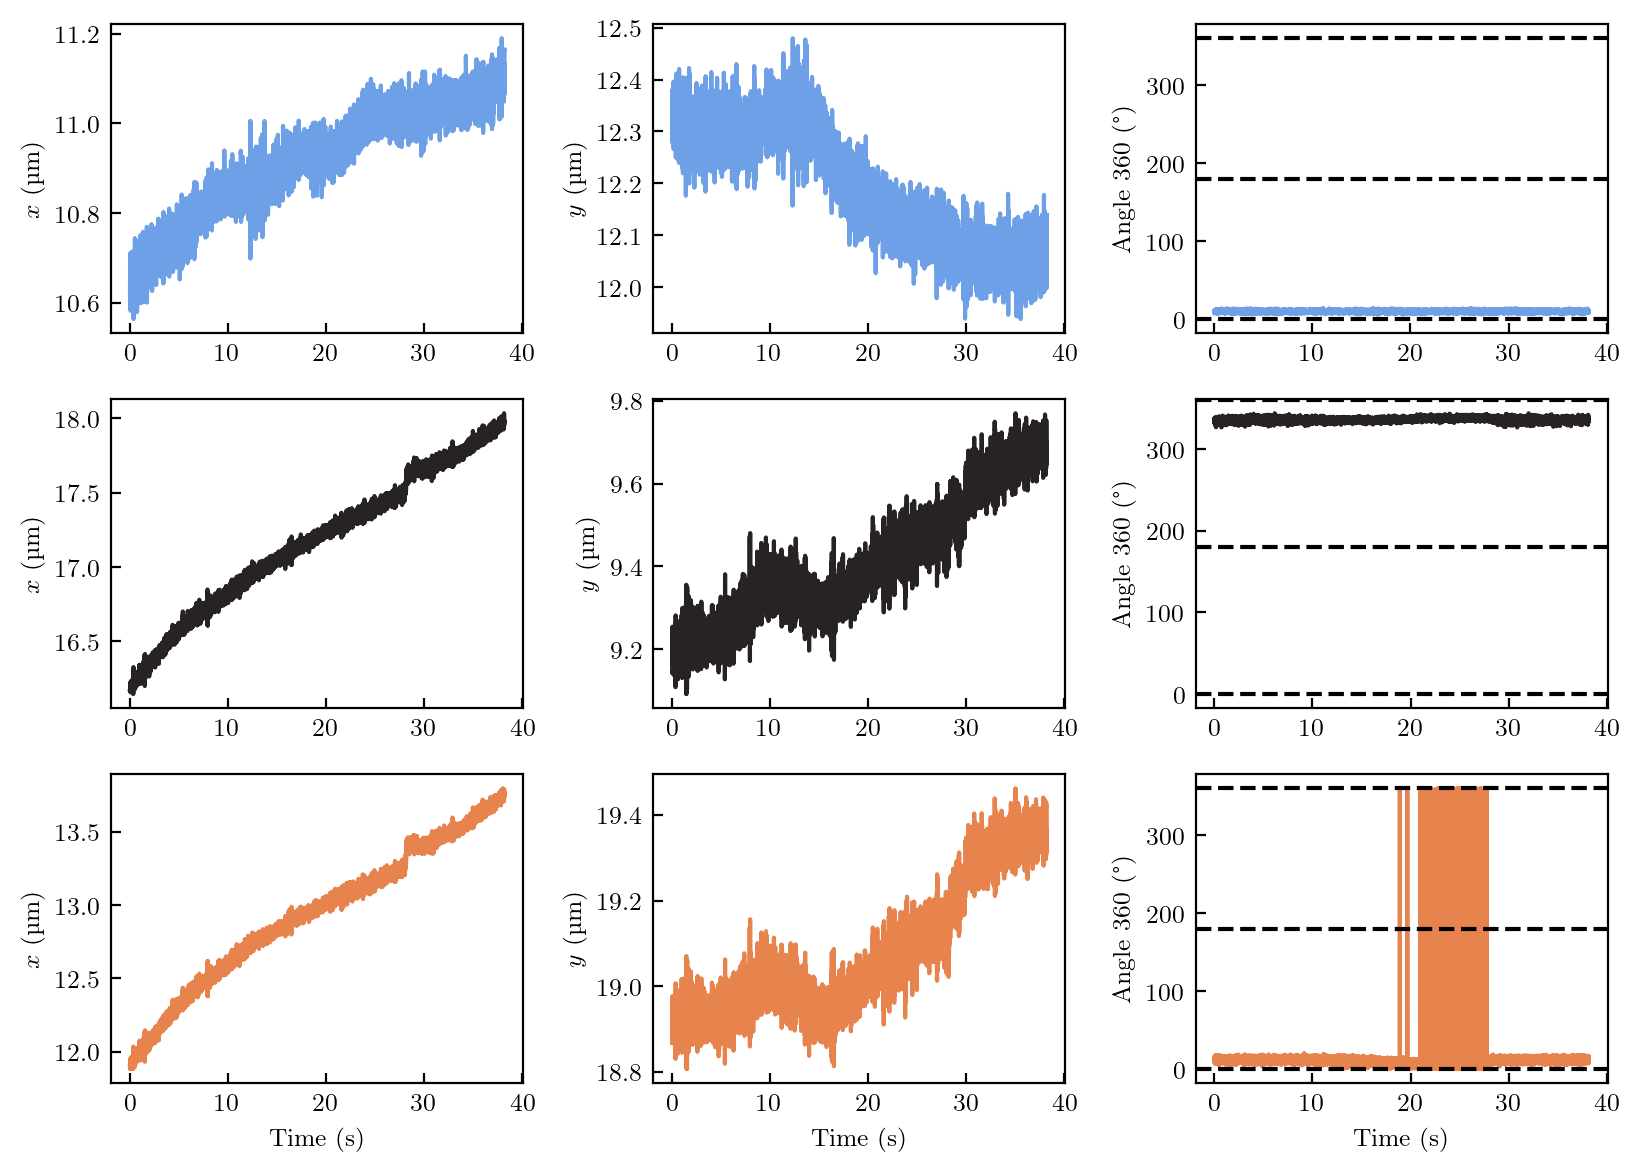

In [405]:
fig, axes = plt.subplots(len(indexes), 3, figsize=(21/2.54, int(len(indexes)*5)/2.54))

for i, ind in enumerate(indexes[::]):
    path = filepaths[ind]
    df = pd.read_csv(path)
    df = df[:Ntime]
    time = df['time_sec'].to_numpy()
    xpx = df['com_x_px'].to_numpy() 
    ypx = df['com_y_px'].to_numpy() 
    x = xpx * calib
    y = ypx * calib 
    theta3 = df['principal_angle_360_deg'].to_numpy()

    start = 0
    stop = len(time) #// 10

    axes[i, 0].plot(time[start:stop], x[start:stop] * 1e6, ls='-', color=colors[ind])
    axes[i, 1].plot(time[start:stop], y[start:stop] * 1e6, ls='-', color=colors[ind])
    axes[i, 2].plot(time[start:stop], theta3[start:stop], ls='-', color=colors[ind])

    # axes[i,2].plot(datas[start:stop,0,0], datas[start:stop,3,0], ls='-')1e-5/1.0Hz/

    axes[i,2].axhline(y=180, ls='--', c='k')
    axes[i,2].axhline(y=0, ls='--', c='k')
    axes[i,2].axhline(y=360, ls='--', c='k')

for j in range(3):
    axes[-1, j].set_xlabel('Time (s)')

for i in range(len(indexes)):
    axes[i, 0].set_ylabel(r'$x$ (\textmu m)')
    axes[i, 1].set_ylabel(r'$y$ (\textmu m)')
    axes[i, 2].set_ylabel('Angle 360 (°)')

del df, time, xpx, ypx, theta3

plt.tight_layout()
plt.show()

In [406]:
# tokeep = [0, 1, 2, 4, 6]

# datas = datas[:,:,tokeep]

# filepaths = [filepaths[i] for i in tokeep]
# colors = sns.diverging_palette(250, 30, l=65, center="dark", as_cmap=False, n=len(filepaths))
# indexes = np.arange(len(filepaths))

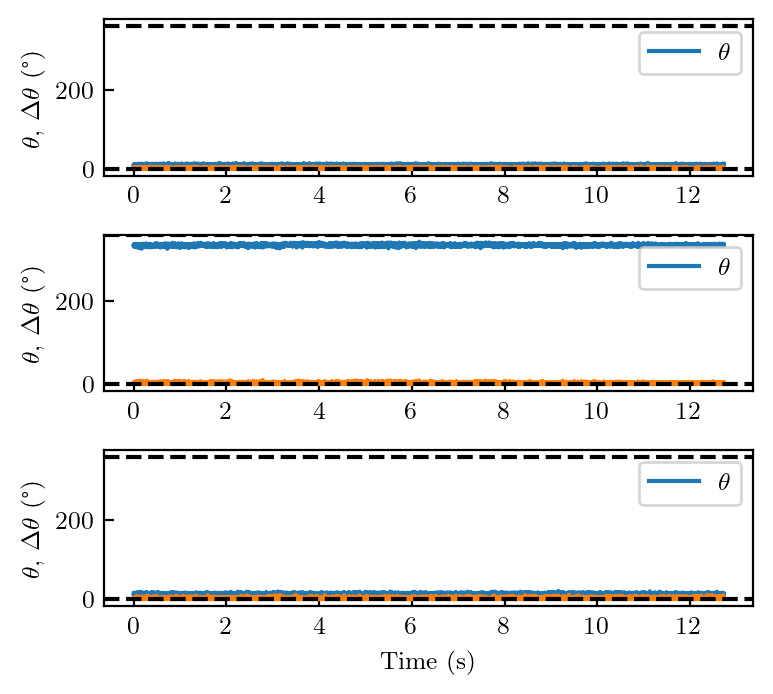

In [407]:
fig, axes = plt.subplots(len(indexes), 1, figsize=(10/2.54, 3*len(indexes)/2.54))

for i, k in enumerate(indexes):
    
    time = datas[:, 0, k]
    theta = datas[:, 3, k]

    dtheta = np.abs(theta[1:]  - theta[:-1])

    start = 0
    stop = len(theta) // 3

    axes[i].plot(time[start:stop], theta[start:stop], ls='-', label=r'$\theta$')
    axes[i].plot(time[start:stop], dtheta[start:stop], ls='-')

for i in range(len(axes)): 
    # axes[i].axhline(y=180, ls='--', c='k')
    axes[i].axhline(y=0, ls='--', c='k')
    axes[i].axhline(y=360, ls='--', c='k')
    # axes[i].axhline(y=-360, ls='--', c='k')
    # axes[i].axhline(y=-180, ls='--', c='k')
    axes[i].set_ylabel(r'$\theta, \, \Delta \theta$ (°)')
    axes[i].legend(loc='upper right')
axes[-1].set_xlabel('Time (s)')

plt.tight_layout()
plt.show()

In [408]:
dframes = np.concatenate((np.arange(1, 100, 1), np.arange(100, 10000, 100)))
dtimes = dframes * dt

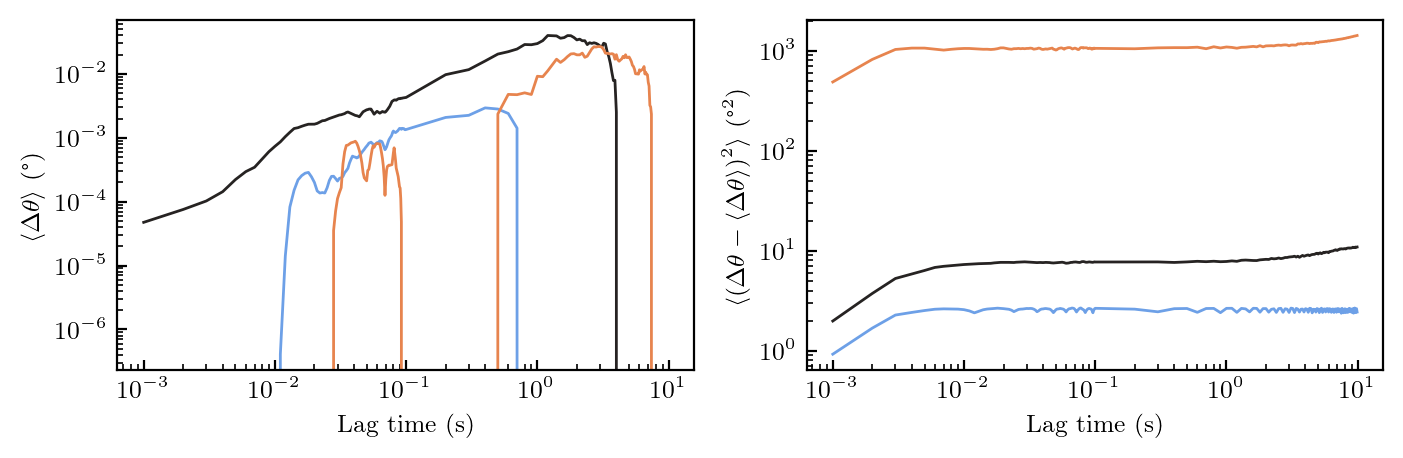

In [409]:
fig, axes = plt.subplots(1, 2, figsize=(18/2.54, 6/2.54))

for k in range(len(filepaths)):
    
    theta = datas[:, 3, k]

    m1 = moment(theta, dframes, n=1, retrieve_mean=False)
    msd = moment(theta, dframes, n=2, retrieve_mean=True)

    axes[0].plot(dtimes, m1, ls='-', color=colors[k], lw=1)
    axes[1].plot(dtimes, msd, ls='-', color=colors[k], lw=1) # marker='o', ms=2, mew=0.2, mec='k', mfc=colors[k])

axes[0].set_ylabel(r'$\langle \Delta \theta \rangle$ (°)')
axes[0].set_xlabel('Lag time (s)')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[1].set_ylabel(r'$\langle \left( \Delta \theta -  \langle \Delta \theta \rangle \right) ^2 \rangle$ (°$^2$)')
axes[1].set_xlabel('Lag time (s)')
axes[1].set_xscale('log')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

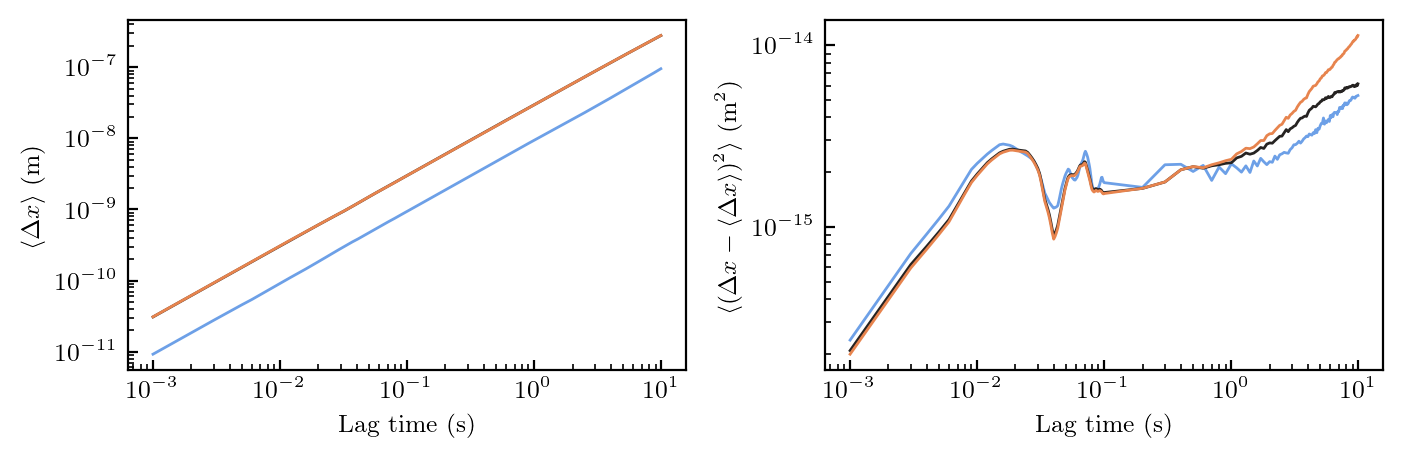

In [410]:
fig, axes = plt.subplots(1, 2, figsize=(18/2.54, 6/2.54))

for k in range(len(filepaths)):
    
    x = datas[:, 1, k]
    y = datas[:, 2, k]

    m1x = moment(x, dframes, n=1, retrieve_mean=False)
    msdx = moment(x, dframes, n=2, retrieve_mean=True)
    m1y = moment(y, dframes, n=1, retrieve_mean=False)
    msdy = moment(y, dframes, n=2, retrieve_mean=True)

    m1r = (np.abs(m1x) + np.abs(m1y)) / 2
    msdr = (msdx + msdy) / 2

    axes[0].plot(dtimes, m1r, ls='-', color=colors[k], lw=1)
    axes[1].plot(dtimes, msdr, ls='-', color=colors[k], lw=1) # marker='o', ms=2, mew=0.2, mec='k', mfc=colors[k])

axes[0].set_ylabel(r'$\langle \Delta x \rangle$ (m)')
axes[0].set_xlabel('Lag time (s)')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[1].set_ylabel(r'$\langle \left( \Delta x -  \langle \Delta x \rangle \right) ^2 \rangle$ (m$^2$)')
axes[1].set_xlabel('Lag time (s)')
axes[1].set_xscale('log')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

[1.13851573 0.35041966]
3.513346283258261e-21

[2.23613834 0.17871208]
1.7887980952746128e-21

[3.31671639 0.11253227]
1.2060120716765954e-21



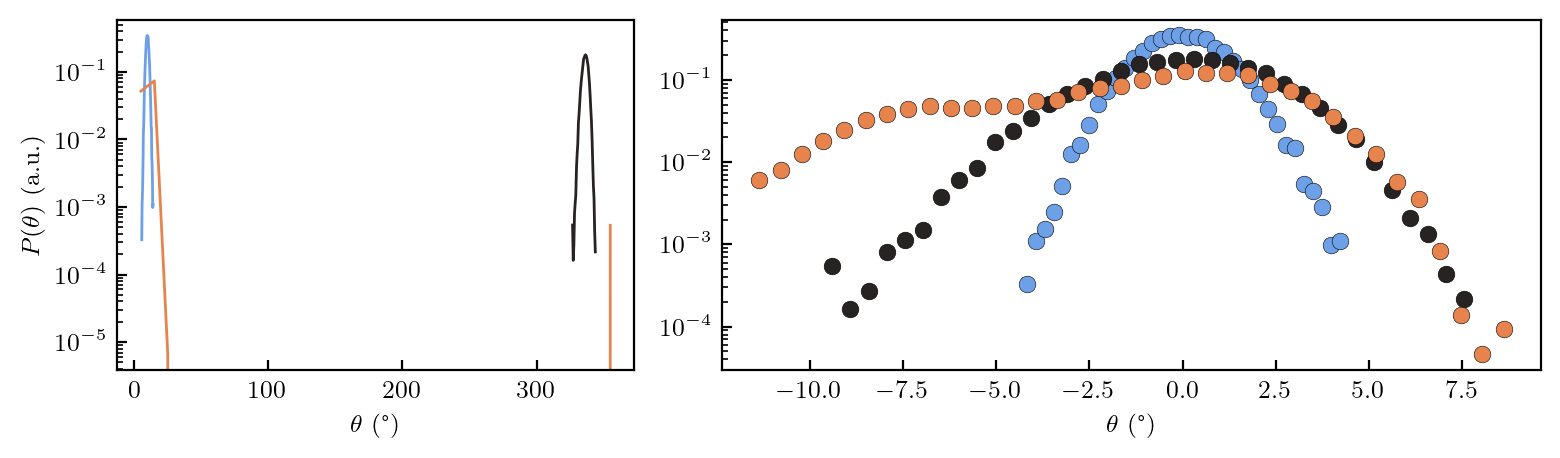

In [411]:
fig = plt.figure(figsize=(20/2.54, 6/2.54))

ax1 = fig.add_subplot(1, 5, (1,2))
ax2 = fig.add_subplot(1, 5, (3,5))

for k in range(len(filepaths)):
    
    theta = datas[:, 3, k]

    prob, bins = pdf(theta, bins=36)
    prob = prob / np.trapezoid(prob, bins)

    ax1.plot(bins, prob, ls='-', color=colors[k], lw=1)

    # Recentering theta
    thetab = theta - np.nanmean(theta)
    prob, bins = pdf(thetab[thetab < 50], bins=36)
    prob = prob / np.trapezoid(prob, bins)

    ax2.plot(bins, prob, ls='', marker='o', color=colors[k], mew=0.2)

    popt, _ = curve_fit(gaussian, bins, prob, p0=[1,1])
    # ax2.plot(bins, gaussian(bins, *popt), ls='-', color=colors[k])
    
    print(popt)
    print(4e-21 / popt[0])
    print()

ax1.set_ylabel(r'$P(\theta)$ (a.u.)')
for ax in [ax1, ax2]:
    ax.set_xlabel(r'$\theta$ (°)')
    # ax.set_xscale('log')
    ax.set_yscale('log')

plt.tight_layout()
plt.show()

In [412]:
dframes = np.array([1, 3, 5])

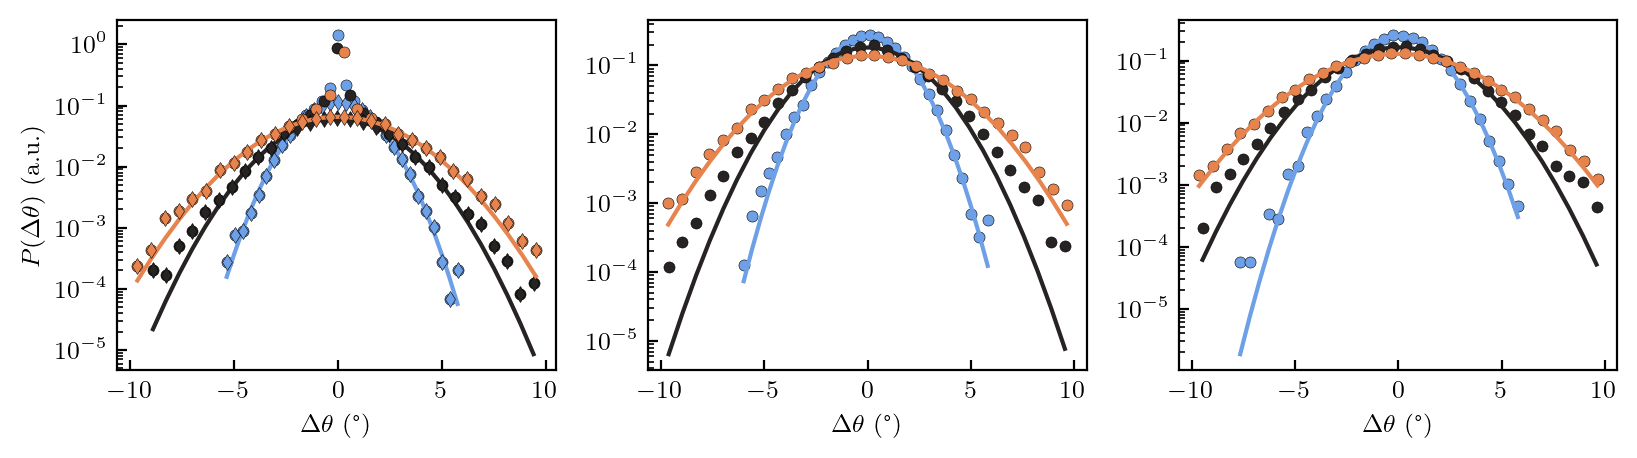

[0.001 0.003 0.005]


In [413]:
fig, axes = plt.subplots(1, len(dframes), figsize=(21/2.54, 6/2.54))

for k in range(len(filepaths)):
    
    theta = datas[:, 3, k]

    for j, d in enumerate(dframes):

        dtheta = theta[d:] - theta[:-d]

        cutoff = 10

        index = np.abs(dtheta) < cutoff
        dtheta = dtheta[index]

        prob, bins = pdf(dtheta[~np.isnan(dtheta)], bins=30)
        prob = prob / np.trapezoid(prob, bins)

        axes[j].plot(bins, prob, ls='', marker='o', color=colors[k], mew=0.2, ms=4)

        if j != 0:
            popt, _ = curve_fit(gaussian, bins, prob, p0=[1, 1])
            axes[j].plot(bins, gaussian(bins, *popt), ls='-', color=colors[k], lw=1.5)
        
        if j == 0:
            threshold = 2   # threshold to be investigated
            popt, _ = curve_fit(gaussian, bins[bins > threshold], prob[bins > threshold], p0=[1, 1])
            axes[j].plot(bins, gaussian(bins, *popt), ls='-', color=colors[k], lw=1.5)
            # Artificially correct the distributions
            index = np.abs(bins) < threshold
            prob[index] = gaussian(bins[index], *popt)
            # prob = prob / np.trapezoid(prob, bins)
            axes[j].plot(bins, prob, ls='', marker='d', color=colors[k], mew=0.2, ms=4)

for j, ax in enumerate(axes):
    ax.set_xlabel(r'$\Delta\theta$ (°)')
    ax.set_yscale('log')
axes[0].set_ylabel(r'$P(\Delta\theta)$ (a.u.)')
        # dtheta = dtheta[index]
# axes[0].set_xscale('log')
# axes[0].set_yscale('log')

plt.tight_layout()
plt.show()

print(dframes * dt)

In [414]:
# spectrum x, theta
# correlations xx, yy, rr, thetatheta, xtheta, etc

In [415]:
def Cxy(x: np.ndarray, y:np.ndarray, lags: np.ndarray=np.arange(1,10,1), retrieve_mean: bool=False):
    if retrieve_mean:
        x = x - np.nanmean(x)
        y = y - np.nanmean(y)
    res = np.zeros_like(lags) * np.nan
    for i, d in enumerate(lags):
        res[i] = np.nanmean(x[:-d] * y[d:])
    return res

def Cxy_fft(x: np.ndarray, y:np.ndarray, retrieve_mean: bool=False):
    if retrieve_mean:
        x = x - np.mean(x)
        y = y - np.mean(y)
    N = len(x)
    fx = np.fft.rfft(x, n=2*N)
    fy = np.fft.rfft(y, n=2*N)
    res = np.fft.irfft(fx * np.conj(fy))[:N]
    # res /= (N - np.arange(N)) # to unbias, but I don't understand
    return res

# def Cdxdy(x: np.ndarray, y:np.ndarray, lags: np.ndarray=np.arange(1,10,1), retrieve_mean: bool=False):
#     res = np.zeros_like(lags) * np.nan
#     if retrieve_mean:
#         for i, d in enumerate(lags):
#             dx = x[d:-d] - x[:-int(2*d)]
#             dy = y[int(2*d):] - y[d:-d]
#             res[i] = np.nanmean((dx - np.nanmean(dx)) * (dy - np.nanmean(dy)))
#     else:
#         for i, d in enumerate(lags):
#             dx = x[d:-d] - x[:-int(2*d)]
#             dy = y[int(2*d):] - y[d:-d]
#             res[i] = np.nanmean(dx * dy)
#     return res

def Cdxdy(x: np.ndarray, y:np.ndarray, lags: np.ndarray=np.arange(1,10,1), disp: int=1, retrieve_mean: bool=False):
    dx = x[disp:] - x[:-disp]
    dy = y[disp:] - y[:-disp]
    return Cxy(x=dx, y=dy, lags=lags, retrieve_mean=retrieve_mean)

def Cdxdy_fft(x: np.ndarray, y:np.ndarray, disp: int=1, retrieve_mean: bool=False):
    dx = x[disp:] - x[:-disp]
    dy = y[disp:] - y[:-disp]
    return Cxy_fft(x=dx, y=dy, retrieve_mean=retrieve_mean)

In [416]:
dframes = np.concatenate((np.arange(1, 100, 1), np.arange(100, 10000, 1)))
dtimes = dframes * dt

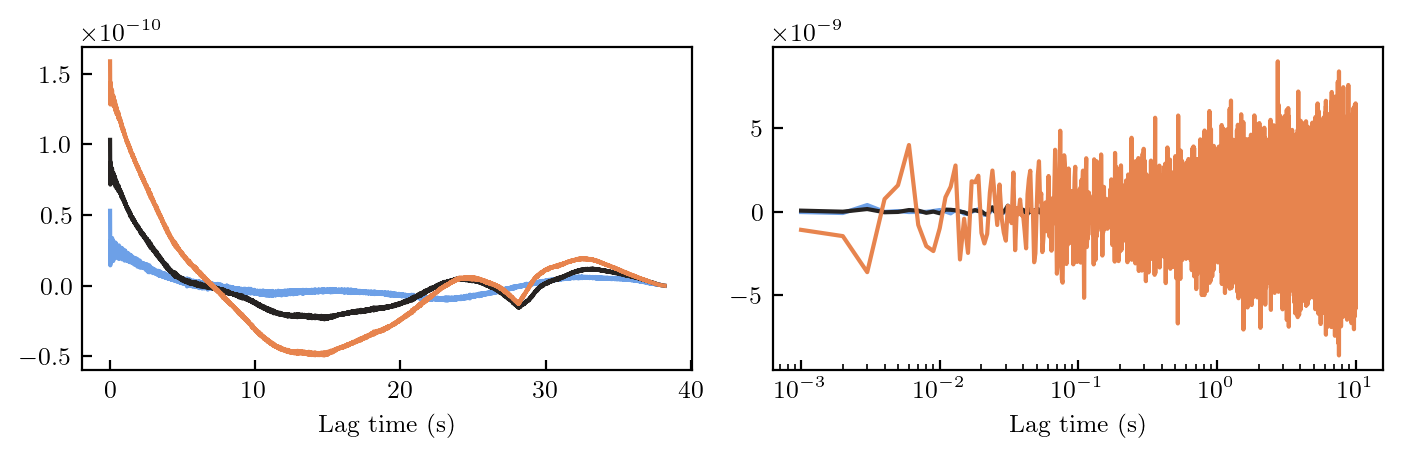

In [426]:
fig, axes = plt.subplots(1, 2, figsize=(18/2.54, 6/2.54))

for k in range(len(filepaths)):
    
    x = datas[:, 1, k]
    y = datas[:, 2, k]
    theta = datas[:, 3, k]

    xd = signal.detrend(x, type='linear')

    # cxx = Cxy(x, y, lags=np.arange(len(x)), retrieve_mean=True)
    cxy = Cxy_fft(xd, xd, retrieve_mean=True)
    # cxy = autocorrelation_biased(x)
    cdxdtheta = Cdxdy(xd, theta, dframes[:], disp=1, retrieve_mean=True)

    axes[0].plot(np.arange(len(x)) * dt, cxy, ls='-', marker='', color=colors[k], mew=0.2)
    axes[1].plot(dtimes[:], cdxdtheta, ls='-', marker='', color=colors[k], mew=0.1, ms=3)

# axes[0].set_ylabel(r'$\langle \Delta x \rangle$ (m)')
axes[0].set_xlabel('Lag time (s)')
# axes[0].set_xscale('log')
# axes[0].set_yscale('log')
# axes[1].set_ylabel(r'$\langle \left( \Delta x -  \langle \Delta x \rangle \right) ^2 \rangle$ (m$^2$)')
axes[1].set_xlabel('Lag time (s)')
axes[1].set_xscale('log')
# axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

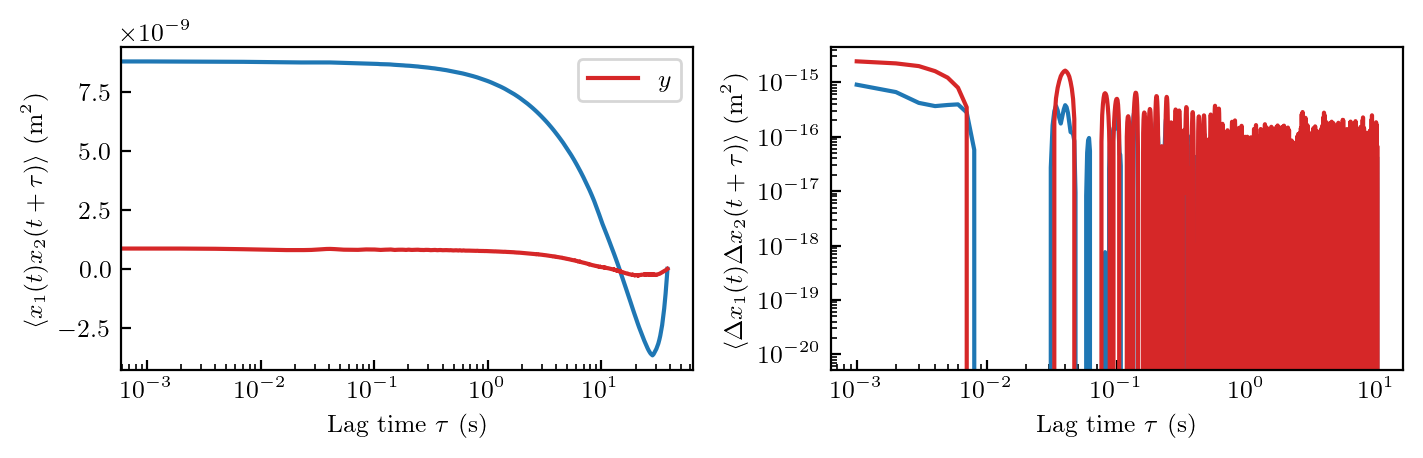

In [425]:
x1 = datas[:,1,1]
y1 = datas[:,2,1]
x2 = datas[:,1,2]
y2 = datas[:,2,2]

cx1x2 = Cxy_fft(x1, x2, retrieve_mean=True)
cy1y2 = Cxy_fft(y1, y2, retrieve_mean=True)

cdx1dx2 = Cdxdy(x1, x2, lags=dframes, disp=10, retrieve_mean=True)
cdy1dy2 = Cdxdy(y1, y2, lags=dframes, disp=10, retrieve_mean=True)
# cdx1dx2 = Cdxdy(x1, x2, lags=dframes, retrieve_mean=True)
# cdy1dy2 = Cdxdy(y1, y2, lags=dframes, retrieve_mean=True)

fig, axes = plt.subplots(1, 2, figsize=(18/2.54, 6/2.54))

axes[0].plot(np.arange(len(x1)) * dt, cx1x2, ls='-', marker='', color='tab:blue', mew=0.2)
axes[0].plot(np.arange(len(y1)) * dt, cy1y2, ls='-', marker='', color='tab:red', mew=0.2, label=r'$y$')

axes[1].plot(dtimes, cdx1dx2, ls='-', marker='', color='tab:blue', mew=0.2)
axes[1].plot(dtimes, cdy1dy2, ls='-', marker='', color='tab:red', mew=0.2)

axes[0].legend()

axes[0].set_ylabel(r'$\langle x_1(t) x_2(t+\tau) \rangle$ (m$^2$)')
axes[0].set_xlabel(r'Lag time $\tau$ (s)')
axes[0].set_xscale('log')
# axes[0].set_yscale('log')
axes[1].set_ylabel(r'$\langle \Delta x_1(t) \Delta x_2(t+\tau) \rangle$ (m$^2$)')
axes[1].set_xlabel(r'Lag time $\tau$ (s)')
axes[1].set_xscale('log')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

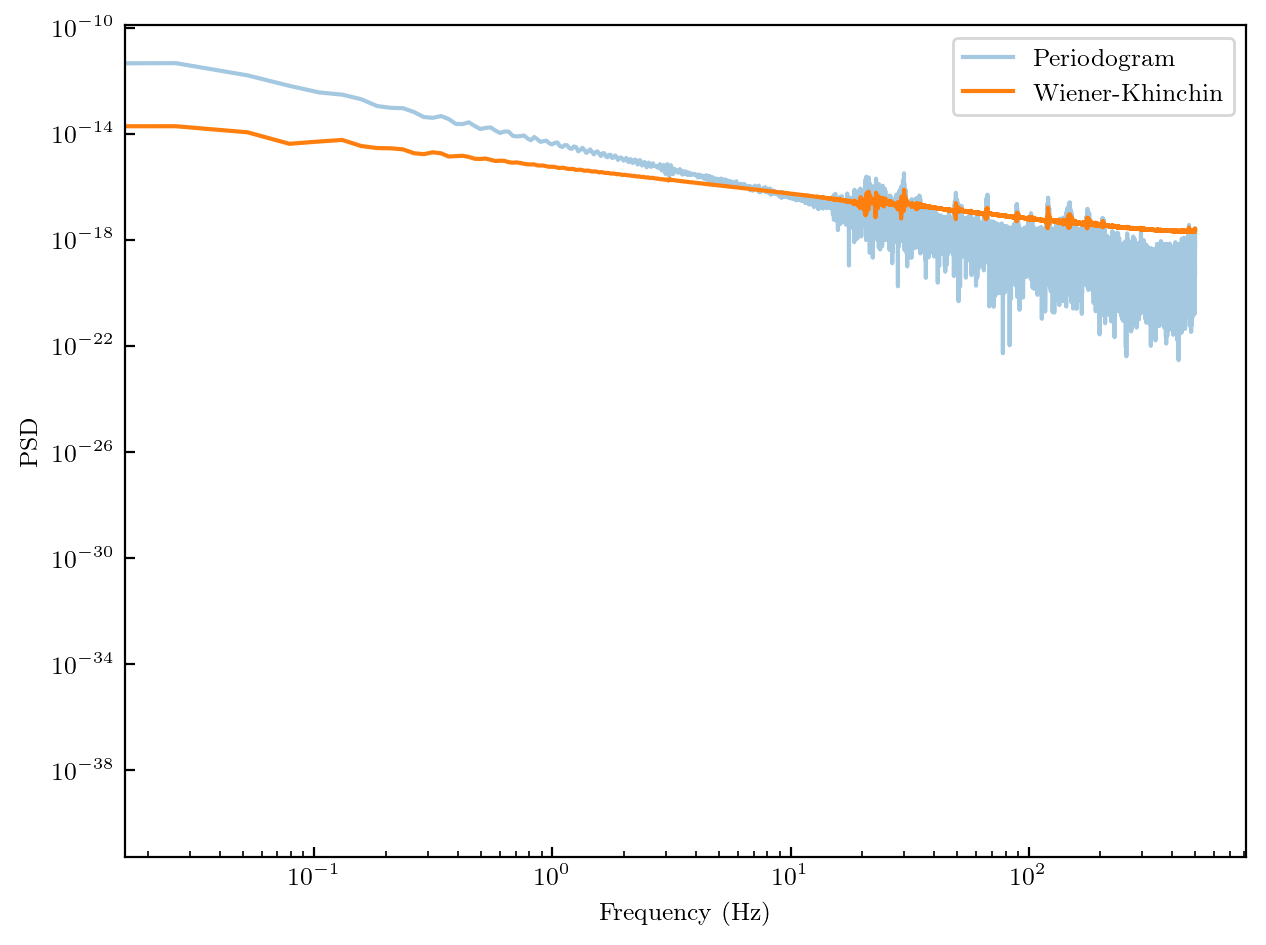

In [427]:
x = datas[:,1,2]

# ── 1. Welch ──────────────────────────────────────────────────────────────
# freqs_welch, psd_welch = signal.welch(x, fs=1/dt, nperseg=256)

# ── 2. Wiener-Khinchin (via autocorrelation) ──────────────────────────────
def autocorrelation_biased(a):
    a = a - np.mean(a)
    N = len(a)
    f = np.fft.rfft(a, n=2*N)
    acf = np.fft.irfft(f * np.conj(f))[:N]
    acf /= N  # divide by N instead of N-lag
    return acf
# acf = Cxy_fft(x, x, retrieve_mean=False) 
x_detrended = signal.detrend(x, type='linear')
acf = autocorrelation_biased(x_detrended)
psd_wk = np.fft.rfft(acf) * dt
freqs_wk = np.fft.rfftfreq(len(acf), d=dt)

# ── 3. Periodogram ────────────────────────────────────────────────────────
freqs_pgram, psd_pgram = signal.periodogram(x, fs=1/dt, scaling='density')

# ── Plot ──────────────────────────────────────────────────────────────────

plt.figure()
plt.loglog(freqs_pgram, psd_pgram, alpha=0.4, label='Periodogram')
plt.plot(freqs_wk, np.abs(psd_wk), label='Wiener-Khinchin')
# plt.semilogy(freqs_welch, psd_welch, lw=2, label='Welch')
plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD')
plt.legend()
plt.tight_layout()
plt.show()

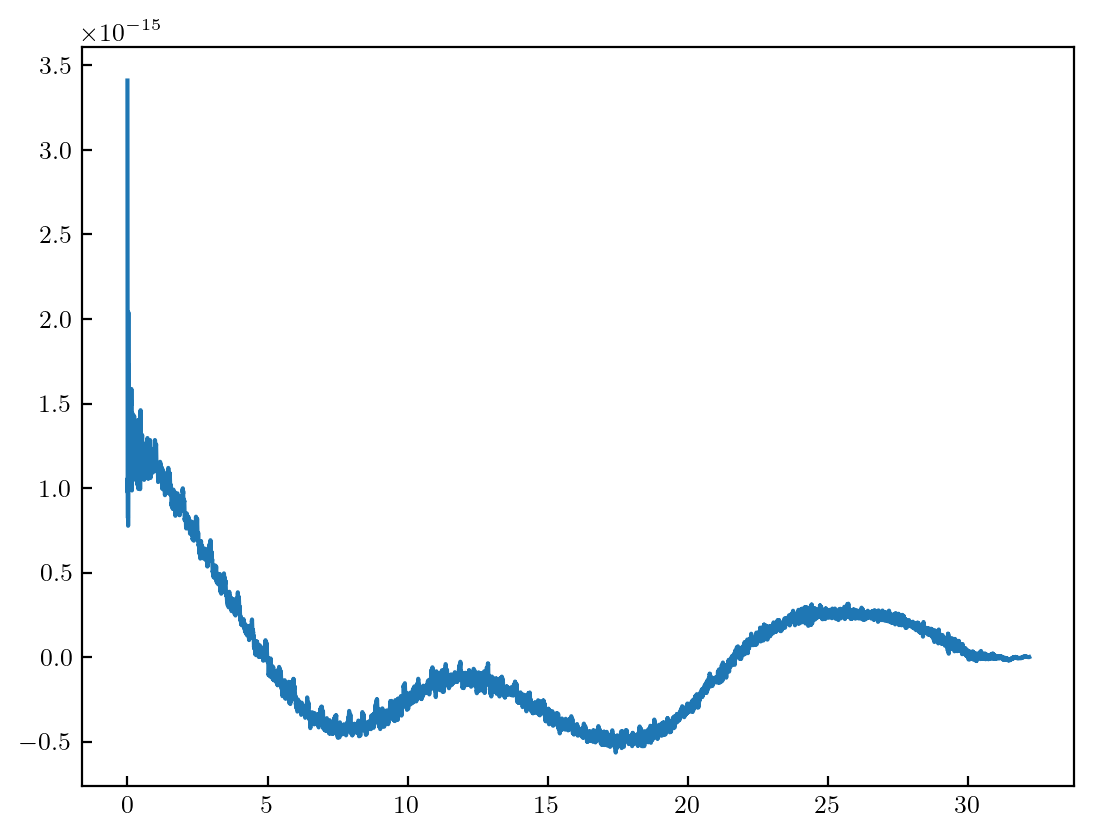

In [421]:
plt.plot(np.arange(len(acf))*dt, acf)

In [422]:
print(np.mean(x))

1.2937511375592907e-05


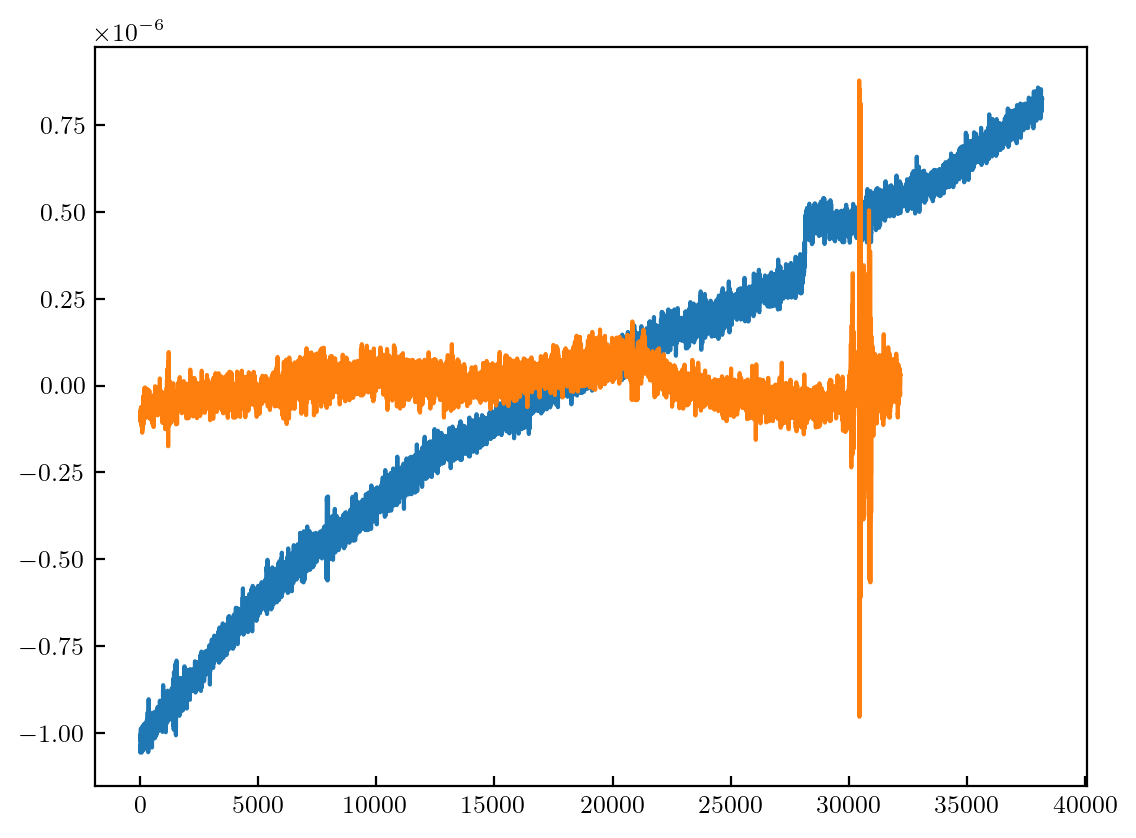

In [423]:
plt.plot(x-np.nanmean(x))
plt.plot(x_detrended)